# Lab 04: Data Cleaning 

Objective: Understand how data cleaning choices alter downstream results and findings. In this lab, you will simulate three different approaches to handling dirty data and analyze how each method tells a different story.

For each question, discuss it with your partner before writing your answer. Be sure to justify your reasoning and reference the data when appropriate.

Your Name(s): Minhaz


**Scenario**: The University launched a 3-month "Campus Wellness Pilot," giving smartwatches to 500 students and staff to see if the program increased physical activity over time. You have been handed the dataset (`wellness_tracker.csv`).

This dataset contains daily step counts for each participant over the 3-month period. It has the following columns:
- `user_id`: The unique identifier for each participant.
- `month`: The month of the recorded step count.
- `day`: The day of the recorded step count.
- `steps`: The number of steps recorded by the smartwatch on that day.

---

## Question 1
Do you think the Campus Wellness Pilot will increase physical activity among participants over the 3-month period? Explain your reasoning.

*Your answer goes here!*

I think the Campus Wellness Pilot will probably increase physical activity, at least at first. Wearing a smartwatch makes people more aware of how much they move, and seeing their step count every day can motivate them to walk more.

However, smartwatch data is noisy:
- Some days logged exactly 0 steps (maybe the user took the watch off or left it charging).
- Some days logged NaN (maybe the Bluetooth app failed to sync to the servers).

In [2]:
# let's take a look at the data

# first we need to import the necessary libraries
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
pd.set_option('display.max_rows', 50)

# load the dataset
df = pd.read_csv('wellness_tracker.csv')
df

,user_id,month,day,steps
0,1,1,1,3651.0
1,1,1,2,0.0
2,1,1,3,4911.0
3,1,1,4,NaN
4,1,1,5,4099.0
...,...,...,...,...
44995,500,3,26,4621.0
44996,500,3,27,0.0
44997,500,3,28,0.0
44998,500,3,29,5342.0


___

## Question 2
What is the unit of observation in this dataset?

*Your answer goes here!*

The unit of observation is one participant on one day. Each row has a user_id, a month, a day, and a step count, so every row records how many steps one person took on one specific day. The dataset has 45,000 rows because 500 participants were tracked for 90 days.

**The Three Cleaning Options**

You must evaluate three different approaches to handling this missing data:
- **Plan A**: Delete any row with a NaN or a 0. 
- **Plan B**: Convert all NaN to 0 steps. 
- **Plan C**: Replace all NaN and 0 values with the overall dataset average. 

___

## Question 3

Before looking at the effects of these plans for cleaning the data, pick which of the three plans you think is the best approach and justify your choice.

*Your answer goes here!*

I think Plan A, dropping rows with 'NaN' or '0', is the best approach. A 'NaN' or a '0' most likely means the watch wasn't worn or didn't sync, not that the person took zero steps. Plan A doesn't make up any numbers and only uses days where we have a believable measurement. 

Plan B treats every missing day as zero steps, which would make people look less active than they really were. 

Plan C fills every gap with the same average, which would hide differences between months and make the data look more unchanged than it is.

In [6]:
# run this cell!

def clean_data(raw_df, strategy):
    """
    Applies a specific cleaning strategy and visualizes the results.
    Accepts strategy 'A', 'B', or 'C'.
    """
    df = raw_df.copy()
    
    if strategy == "A":
        # The Purge: Drop NaNs and zeros
        df = df.dropna(subset=['steps'])
        df = df[df['steps'] > 0]
        title = "Strategy A: Drop Missing & Zeros"
        
    elif strategy == "B":
        # The Pessimist: Assume NaNs are 0s
        df['steps'] = df['steps'].fillna(0)
        title = "Strategy B: Convert Missing to Zeros"
        
    elif strategy == "C":
        # The Imputer: Replace NaNs and 0s with the overall mean
        overall_mean = df[df['steps'] > 0]['steps'].mean()
        df['steps'] = df['steps'].replace(0, np.nan)
        df['steps'] = df['steps'].fillna(overall_mean)
        title = "Strategy C: Impute with Global Mean"
        
    else:
        raise ValueError("Strategy must be 'A', 'B', or 'C'")
    
    return df

def compute_metrics(df):
    # Calculate metrics
    month_1_avg = df[df['month'] == 1]['steps'].mean()
    month_1_records = len(df[df['month'] == 1])

    month_2_avg = df[df['month'] == 2]['steps'].mean()
    month_2_records = len(df[df['month'] == 2])

    month_3_avg = df[df['month'] == 3]['steps'].mean()
    month_3_records = len(df[df['month'] == 3])
    
    # Print summary
    title = f"Cleaning Plan {cleaning_plan}"
    print(f"--- {title} ---")
    print(f"Month 1 Average Steps: {month_1_avg:.0f}")
    print(f"Month 2 Average Steps: {month_2_avg:.0f}")
    print(f"Month 3 Average Steps: {month_3_avg:.0f}")
    print(f"Total valid records remaining in Month 1: {month_1_records}")
    print(f"Total valid records remaining in Month 2: {month_2_records}")
    print(f"Total valid records remaining in Month 3: {month_3_records}")
    print("-" * 30 + "\n")
    
    # Visualize
    plt.figure(figsize=(8, 5))
    sns.barplot(data=df, x='month', y='steps', errorbar=None, hue='month', legend=False)
    plt.title(f"Average Steps by Month\n({title})")
    plt.ylabel("Average Daily Steps")
    plt.xlabel("Month of Program")
    plt.ylim(0, 10000)
    plt.show()


Input your preferred data cleaning strategy below.

In [21]:
cleaning_plan = "C" # Choose between "A", "B", or "C" based on your preferred data cleaning strategy

Now, let's clean the data!

In [22]:
cleaned_df = clean_data(df, cleaning_plan)
cleaned_df.head(10)

,user_id,month,day,steps
0,1,1,1,3651.000000
1,1,1,2,6203.958985
2,1,1,3,4911.000000
3,1,1,4,6203.958985
4,1,1,5,4099.000000
5,1,1,6,2751.000000
6,1,1,7,2807.000000
7,1,1,8,719.000000
8,1,1,9,4282.000000
9,1,1,10,2904.000000


Let's compute statistics for each month and visualize them using a histogram.

--- Cleaning Plan C ---
Month 1 Average Steps: 6066
Month 2 Average Steps: 6197
Month 3 Average Steps: 6349
Total valid records remaining in Month 1: 15000
Total valid records remaining in Month 2: 15000
Total valid records remaining in Month 3: 15000
------------------------------



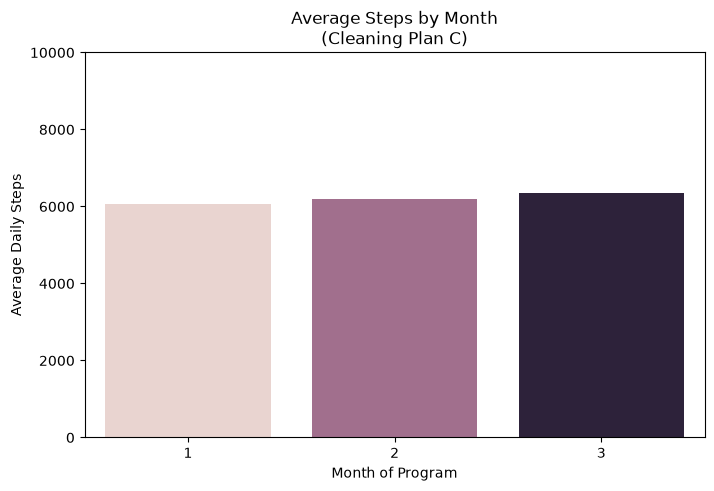

In [23]:
compute_metrics(cleaned_df)

___

## Question 4

Based on the computed metrics and visualizations, do you think the Campus Wellness Pilot increase physical activity over the 3-month period? Explain your reasoning. Is there any information in the computed metrics that might suggest the visualization is misleading?

*Your answer goes here!*

Based on Plan A, the pilot seems to increase physical activity. Average daily steps rise from 6044 in month 1 to 6195 in month 2 and 6438 in month 3, and the bar chart shows the same increasing trend. 

But, the calculated numbers suggest the visualization could be misleading. The number of valid records drops each month, from 12,999 in month 1 to 11,194 in month 2 and 9,307 in month 3. That means a growing share of the data was removed as NaN or zero values, and the chart doesn't show this. 

## Question 5

Does this finding align with your expectations from Question 1? Why or why not?

*Your answer goes here!*

Yes,this finding matches my expectation from Question 1. I predicted that the pilot would probably increase physical activity, and under Plan A the average steps do rise a little each month, from 6044 to 6438. 

But, I'm not fully confident the increase is real. I expected the effect might fade as the novelty wore off, but the data shows steady growth instead.  the result lines up with what I expected, but the missing data makes me unsure whether it reflects a real change in behavior or just a side effect of how I cleaned the data.

## Question 6

Now, go back and try the other two data cleaning plans. You can do this by changing the value of the `cleaning_plan` variable and re-running cells where you create the cleaned dataset and compute the statistics. 

Using the results from the other two cleaning plans, do you think your choice of cleaning plan affected the results? Explain your reasoning. Knowning these results, would you make the same choice again? Why or why not?

*Your answer goes here!*

Yes, my choice changed the results. With Plan A, steps went up from 6044 to 6438. With Plan C, steps went up from 6066 to 6349. With Plan B, steps went down from 5238 to 3994. That is the opposite story.

Plan B does this because it counts every missing day as zero steps. More days go missing each month, so the average keeps dropping. That doesn't mean people walked less. It means the watches stopped recording.

Plan C shows a smaller rise than Plan A because it fills the gaps with one average number. That makes all the months look more alike.

## Question 7
Suppose your analysis will be used to inform the college's decision to expand the program. The administration wants a simple "Yes" or "No" on whether to spend $500,000 expanding this program next year. Based on your understanding of the data's flaws, what do you tell them, and which chart do you show to justify it?

*Your answer goes here!*


My answer would be "Probably No, not yet." The data is too messy to support spending the money on it.

The main problem is missing data. Many days have zero or no steps recorded, and this gets worse every month. By month 3.

This matters because the result depends on how we handle those days. If we delete them (Plan A) or fill them with the average (Plan C), steps go up a little. If we count them as zero (Plan B), steps go down a lot. When the answer flips like this, we can't trust it.

Also, we have no group of people without smartwatches to compare with, so we can't be sure the program caused any change.

Most probably, I would show the chart that puts the three plans' monthly averages side by side. It shows that the three methods tell three different stories. I would recommend fixing the watch problems and running the pilot again with a comparison group before deciding.

